In [2]:
pip install folium


   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]

Note: you may need to restart the kernel to use updated packages.


In [4]:
#EDA on the classic NYC Airbnb Open Data 2019 dataset (~49k listings). Covering price outliers, a bit of text mining on listing names, geospatial mapping with folium, host behaviour clustering, and a simple price-prediction model at the end.
#Dataset: NYC Airbnb Open Data 2019 (Kaggle / Inside Airbnb)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import re

import folium
from folium.plugins import HeatMap

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

(48895, 16)
dropped 11 zero-price listings


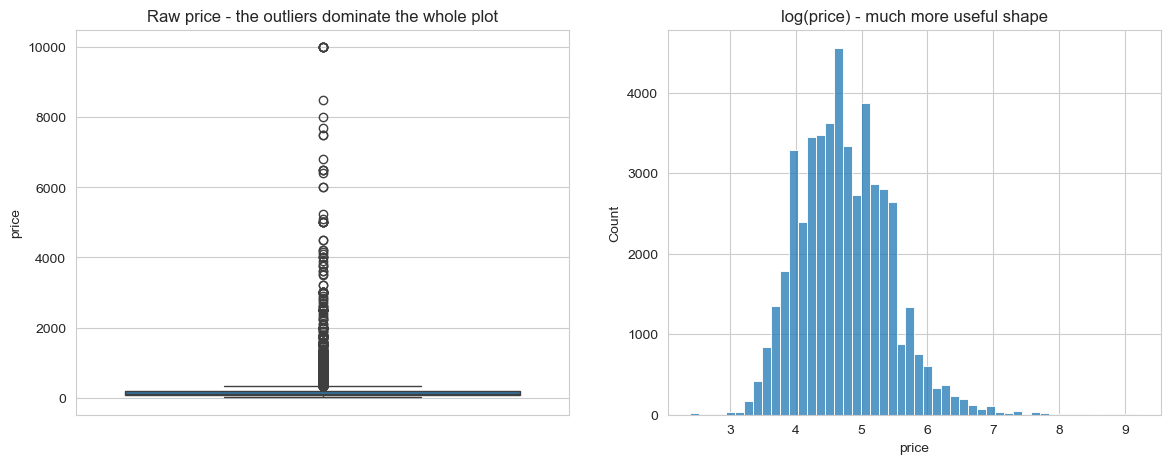

0.500     106.0
0.900     269.0
0.990     799.0
0.999    3000.0
Name: price, dtype: float64
0.500      3.000
0.900     28.000
0.990     45.000
0.999    354.702
Name: minimum_nights, dtype: float64


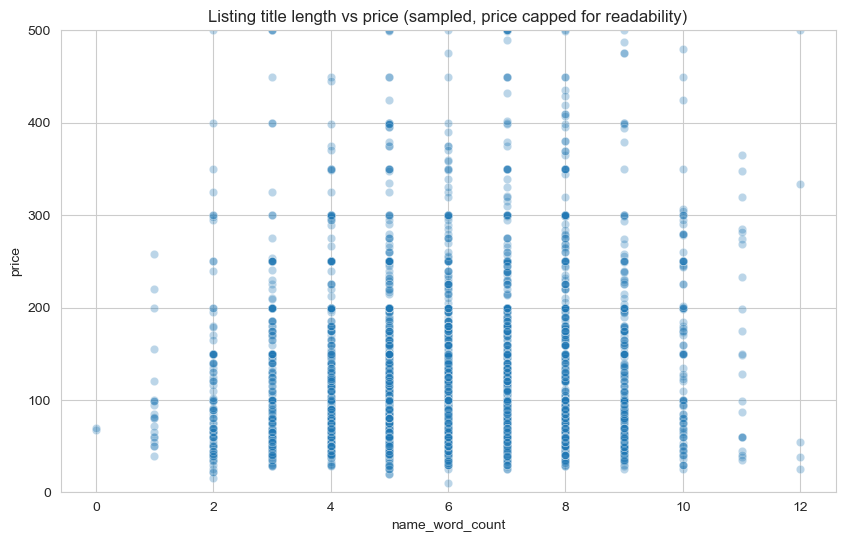

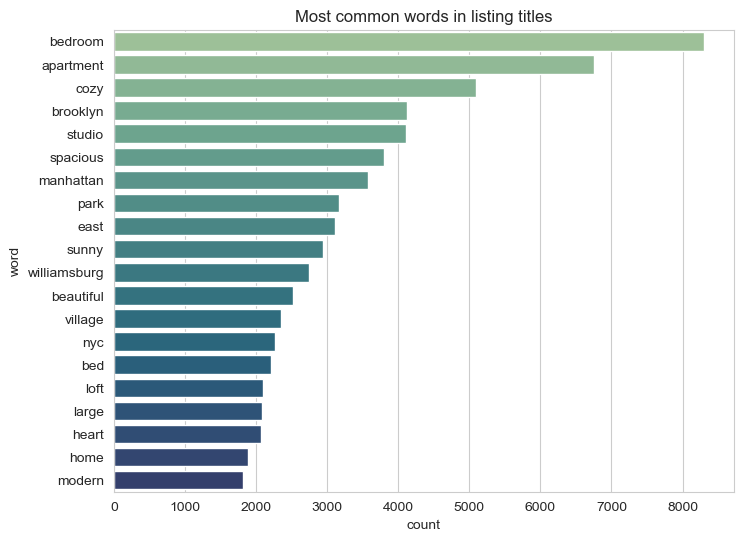

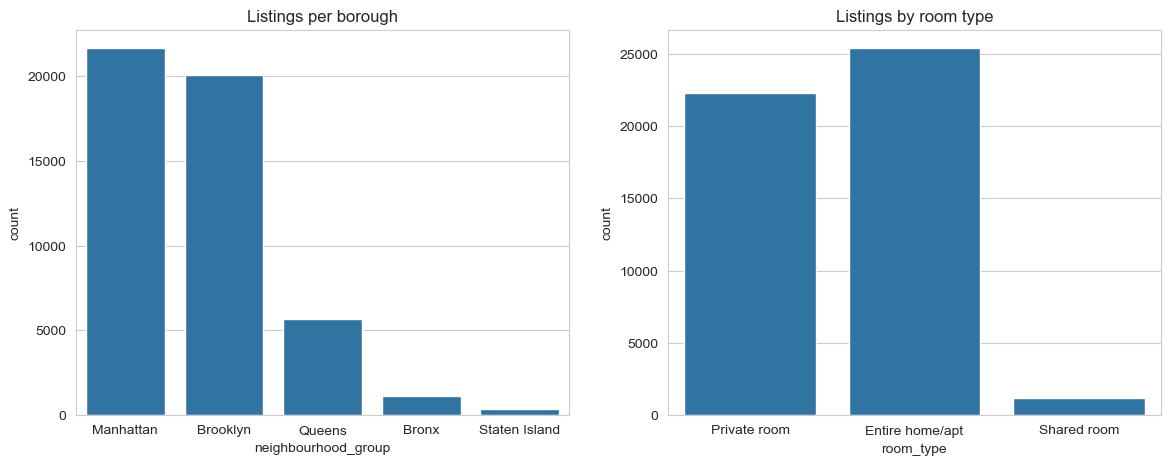

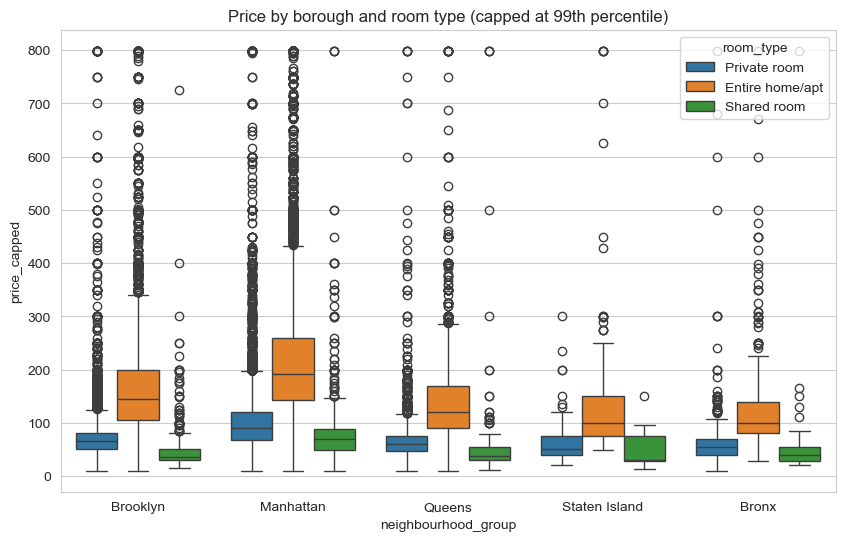

(37455, 7)


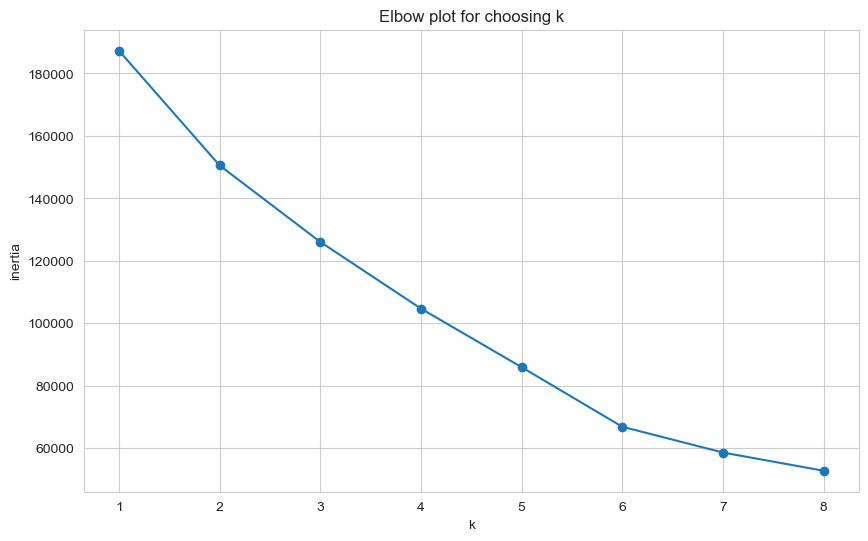

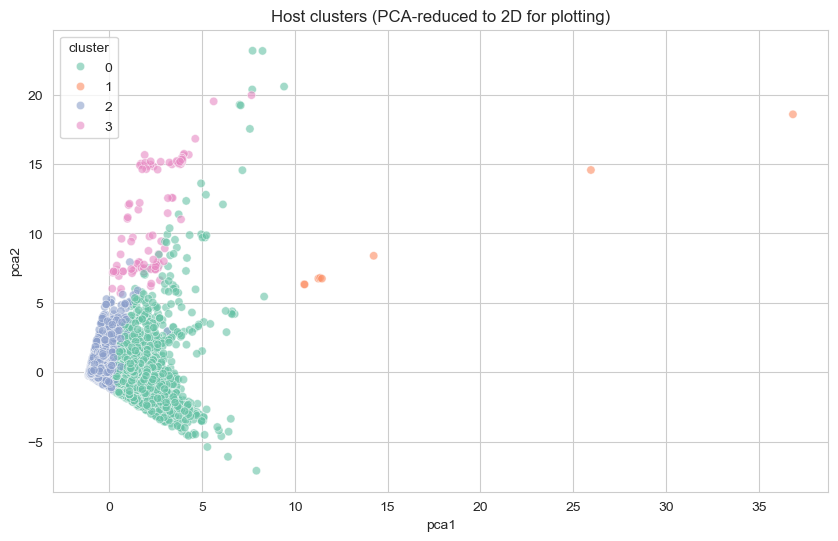

R2: 0.647
MAE (approx $): 42.23


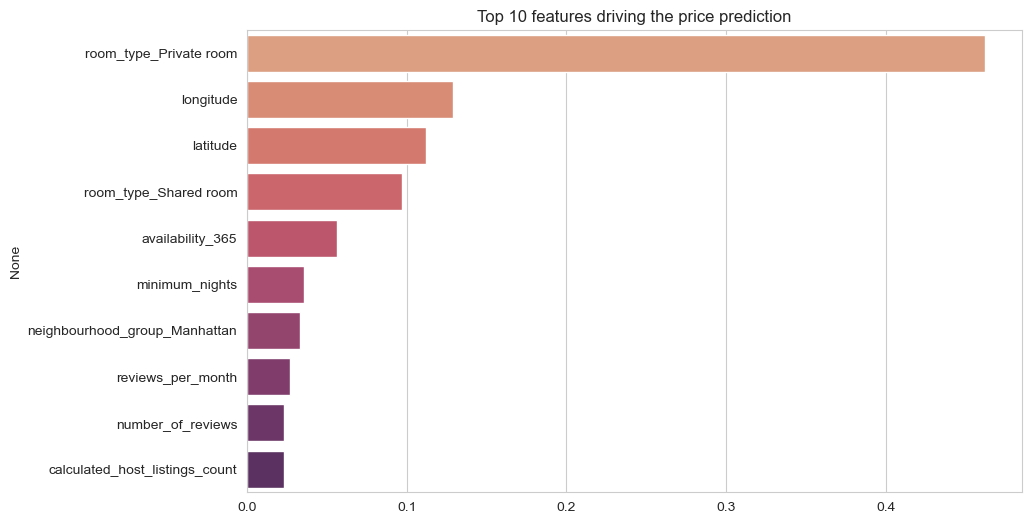

In [5]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 50)

#if folium isn't installed, run `pip install folium` first

DATA_PATH = Path(r"C:\Users\Afdal Hussain\Desktop\Python Projects\Datasets\NYCABNB_Dataset\AB_NYC_2019.csv")
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head(3)

df.isna().sum()


df["name"] = df["name"].fillna("")
df["host_name"] = df["host_name"].fillna("Unknown")
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)
df["last_review"] = pd.to_datetime(df["last_review"])

#a small number of listings are priced at $0, they arent real prices so im dropping them
before = len(df)
df = df[df["price"] > 0].copy()
print(f"dropped {before - len(df)} zero-price listings")

#2. Price outliers

#Airbnb price data is always heavily skewed, a few "listings" at $10,000/night that are obviously either jokes or placeholder listings.


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(y=df["price"], ax=axes[0])
axes[0].set_title("Raw price - the outliers dominate the whole plot")
sns.histplot(np.log1p(df["price"]), bins=50, ax=axes[1])
axes[1].set_title("log(price) - much more useful shape")
plt.show()

print(df["price"].quantile([0.5, 0.9, 0.99, 0.999]))

# Median price is ~$106/night, but the top 0.1% are priced at $3,000+. Rather than delete these outright (they might be genuinely real, just rare), I'll cap a working copy at the 99th percentile for visuals so extreme values don't wreck every chart, but keep the raw `price` column intact for anything that needs the true distribution.
df["price_capped"] = df["price"].clip(upper=df["price"].quantile(0.99))


# Worth a quick look at `minimum_nights` too - this column is (in)famous for weird outliers in this dataset (some listings require 1000+ minimum nights, which is clearly not a realistic booking).
print(df["minimum_nights"].quantile([0.5, 0.9, 0.99, 0.999]))

# 99.9th percentile jumps to 355 nights - almost a full year. Definitely some data-entry noise in the tail, worth remembering if this column ever gets used in modelling (I clip it later on for exactly this reason).
#3. A little text mining on listing names
# Hosts write their own listing titles, which means there's a mini marketing-copy dataset hiding in `name`. Worth a quick look at what words show up most and whether longer titles correlate with price at all.


df["name_word_count"] = df["name"].apply(lambda x: len(x.split()))

fig, ax = plt.subplots()
sns.scatterplot(data=df.sample(3000, random_state=42), x="name_word_count", y="price", alpha=0.3, ax=ax)
ax.set_ylim(0, 500)
ax.set_title("Listing title length vs price (sampled, price capped for readability)")
plt.show()


stopwords = {"the", "a", "in", "of", "and", "with", "to", "for", "near", "br", "2", "1", "private", "room", "apt"}
words = []
for name in df["name"]:
    tokens = re.findall(r"[a-z']+", name.lower())
    words.extend(t for t in tokens if t not in stopwords and len(t) > 2)

top_words = Counter(words).most_common(20)
word_df = pd.DataFrame(top_words, columns=["word", "count"])

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=word_df, x="count", y="word", hue="word", palette="crest", legend=False, ax=ax)
ax.set_title("Most common words in listing titles")
plt.show()

# No strong relationship between title length and price - hosts don't seem to write longer descriptions for pricier places. The word list is exactly what you'd expect for a marketplace: location call-outs (park, village, williamsburg), amenity words (cozy, spacious, sunny), and a lot of "bedroom"/"studio" type descriptors.


#4. Where and what - boroughs & room types

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x="neighbourhood_group", order=df["neighbourhood_group"].value_counts().index, ax=axes[0])
axes[0].set_title("Listings per borough")
sns.countplot(data=df, x="room_type", ax=axes[1])
axes[1].set_title("Listings by room type")
plt.show()


fig, ax = plt.subplots()
sns.boxplot(data=df, x="neighbourhood_group", y="price_capped", hue="room_type", ax=ax)
ax.set_title("Price by borough and room type (capped at 99th percentile)")
plt.show()

# Manhattan and Brooklyn dominate listing volume, and Manhattan is consistently the most expensive borough across every room type - no surprise, but nice to confirm with actual numbers rather than assumption.

#5. Geospatial view (this is where folium comes in)

sample = df.sample(3000, random_state=42)
nyc_map = folium.Map(location=[40.7128, -74.0060], zoom_start=11, tiles="cartodbpositron")

room_colors = {"Entire home/apt": "crimson", "Private room": "steelblue", "Shared room": "seagreen"}
for _, row in sample.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=2,
        color=room_colors.get(row["room_type"], "gray"),
        fill=True,
        fill_opacity=0.5,
    ).add_to(nyc_map)

nyc_map


# Sampled down to 3,000 points so the map actually stays responsive - plotting all ~49k markers individually would grind the browser to a halt. Red = entire home/apt, blue = private room, green = shared room. Manhattan is almost solid red/crimson (whole-unit rentals), while the outer boroughs show more of a blue/private-room mix.
heat_map = folium.Map(location=[40.7128, -74.0060], zoom_start=11, tiles="cartodbpositron")
HeatMap(df[["latitude", "longitude"]].values.tolist(), radius=6, blur=8).add_to(heat_map)
heat_map


#The heatmap can handle the full dataset since it's aggregating density rather than drawing individual markers. Listing density is heavily concentrated in Manhattan below Central Park and in north/west Brooklyn (Williamsburg, Bushwick) - matches the tourist and young-professional neighbourhoods you'd expect.

#6. Host behaviour clustering
# Rather than clustering individual listings, it's more interesting to cluster at the*host* level - are there distinct "types" of host on this platform (single-room casual host vs. multi-property investor, for example)?

host_agg = df.groupby(["host_id", "host_name"]).agg(
    n_listings=("id", "count"),
    avg_price=("price", "mean"),
    avg_availability=("availability_365", "mean"),
    avg_reviews_per_month=("reviews_per_month", "mean"),
    avg_minimum_nights=("minimum_nights", "mean"),
).reset_index()

print(host_agg.shape)
host_agg.describe()

cluster_features = ["n_listings", "avg_price", "avg_availability", "avg_reviews_per_month", "avg_minimum_nights"]

X = host_agg[cluster_features].copy()
X["avg_minimum_nights"] = X["avg_minimum_nights"].clip(upper=365)  # same outlier issue as before

X_scaled = StandardScaler().fit_transform(X)

inertias = []
for k in range(1, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots()
ax.plot(range(1, 9), inertias, marker="o")
ax.set_xlabel("k")
ax.set_ylabel("inertia")
ax.set_title("Elbow plot for choosing k")
plt.show()


kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
host_agg["cluster"] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
host_agg["pca1"] = coords[:, 0]
host_agg["pca2"] = coords[:, 1]

fig, ax = plt.subplots()
sns.scatterplot(data=host_agg, x="pca1", y="pca2", hue="cluster", palette="Set2", alpha=0.6, ax=ax)
ax.set_title("Host clusters (PCA-reduced to 2D for plotting)")
plt.show()

host_agg.groupby("cluster")[cluster_features].mean().round(1)

# Four fairly distinct host profiles usually fall out of this: casual single-listing hosts with modest availability, highly-available "always on" hosts, multi-listing hosts running several properties at once (the investor/management-company type), and a smaller premium-priced cluster. Worth checking the actual numbers above against your run since `random_state` keeps it reproducible but cluster *labels* (0/1/2/3) aren't meaningful - only the group profiles are.
#7. A simple price prediction model
# Given how much structure showed up above (borough, room type, availability all clearly move price), a quick model is worth trying - kept deliberately simple: one RandomForestRegressor, no heavy tuning, predicting log(price) since raw price is so skewed.

model_df = df[df["price"] <= df["price"].quantile(0.99)].copy()  # drop the extreme tail for a fairer model
model_df["log_price"] = np.log1p(model_df["price"])

features = [
    "room_type", "neighbourhood_group", "minimum_nights", "number_of_reviews",
    "reviews_per_month", "availability_365", "calculated_host_listings_count",
    "latitude", "longitude",
]

X = pd.get_dummies(model_df[features], columns=["room_type", "neighbourhood_group"], drop_first=True)
y = model_df["log_price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
preds = rf.predict(X_test)

r2 = r2_score(y_test, preds)
mae_dollars = mean_absolute_error(np.expm1(y_test), np.expm1(preds))
print(f"R2: {r2:.3f}")
print(f"MAE (approx $): {mae_dollars:.2f}")

# ~0.65 R² and roughly $42 average error is genuinely solid for this dataset without any tuning - `price` here is famously noisy (hosts often price emotionally/competitively rather than purely on listing attributes), so this is a good stopping point rather than something to keep squeezing.

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="flare", legend=False, ax=ax)
ax.set_title("Top 10 features driving the price prediction")
plt.show()

#Key takeaways

#**Price is heavily right-skewed** - median ~$106/night but a long luxury tail; log transform is essential for both visuals and modelling.
#- **Manhattan commands a clear premium** across every room type - location is doing a  lot of the work in price.
#- **Listing titles barely matter for price** - length has no real relationship, and the vocabulary is fairly generic across the board.
#- **Hosts split into distinct behavioural groups** - casual single-listing hosts vs. multi-property "portfolio" hosts vs. always-available high-frequency hosts.
#- **A simple Random Forest gets you ~65% of the variance in price** with no tuning, using just location, room type, and availability/review behaviour - room type and neighbourhood group dominate the feature importances.

#Possible next steps
#- Bring in `last_review` as a recency feature - could reveal "ghost listings" that haven't been active in years
#- Try a gradient boosting model (XGBoost/LightGBM) to see how much further price R² can realistically go
#- Layer host clusters back onto the geospatial map to see if certain host types cluster geographically too